# Aula 05 - Árvores de Decisão: Churn de Clientes de Internet
# Objetivos:
# - Entender árvores de decisão como modelo de classificação.
# - Treinar um modelo para prever churn (cancelamento de plano).
# - Interpretar as regras aprendidas pela árvore.
# - Discutir overfitting e hiperparâmetros básicos (max_depth).

## Contexto

Você é analista de dados em uma operadora de internet em São Paulo.  
O time de marketing quer identificar quais clientes têm maior risco de **churn** (cancelar o plano) nos próximos meses, para oferecer promoções e planos especiais de retenção.

Vamos treinar uma **árvore de decisão** para classificar clientes em:
- 0 = Não vai churnar (tendência a permanecer)
- 1 = Vai churnar (alto risco de cancelamento)

Seção 1 – Setup e dados

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid", palette="muted")

Seção 2 - Carregando/gerando dados

OBS: criamos dados “realistas” com uma regra por trás, para a árvore tentar descobrir.

In [16]:
# Gerando um dataset sintético de churn (para exemplo)
np.random.seed(42)
n = 1000

df = pd.DataFrame({
    "idade": np.random.randint(18, 80, size=n),
    "tempo_de_casa": np.random.randint(1, 60, size=n),  # em meses
    "valor_mensal": np.random.choice([79.9, 99.9, 129.9, 159.9], size=n),
    "tipo_plano": np.random.choice(["Basico", "Intermediario", "Premium"], size=n),
    "atrasos_pagamento": np.random.poisson(lam=1.5, size=n),
    "usa_app": np.random.choice([0, 1], size=n),
    "atendimentos_suporte": np.random.poisson(lam=0.8, size=n)
})

# Regra "escondida" para gerar churn
prob_churn = (
    0.15
    + 0.25*(df["tempo_de_casa"] < 6)
    + 0.20*(df["atrasos_pagamento"] >= 3)
    + 0.15*(df["atendimentos_suporte"] >= 2)
    + 0.10*(df["valor_mensal"] >= 129.9)
)
prob_churn = np.clip(prob_churn, 0, 0.9)

df["churn"] = np.random.binomial(1, prob_churn)

df.head()

,idade,tempo_de_casa,valor_mensal,tipo_plano,atrasos_pagamento,usa_app,atendimentos_suporte,churn
0,56,11,99.9,Intermediario,2,1,0,0
1,69,21,159.9,Basico,1,1,1,1
2,46,26,79.9,Premium,3,1,0,1
3,32,25,99.9,Intermediario,0,0,1,0
4,60,22,79.9,Intermediario,2,1,1,0


**Observação:** estamos simulando um conjunto de dados com uma "regra escondida".
A ideia é que a árvore de decisão tente descobrir essas regras a partir dos dados.

Seção 2 – EDA rápida

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   idade                 1000 non-null   int64  
 1   tempo_de_casa         1000 non-null   int64  
 2   valor_mensal          1000 non-null   float64
 3   tipo_plano            1000 non-null   object 
 4   atrasos_pagamento     1000 non-null   int64  
 5   usa_app               1000 non-null   int64  
 6   atendimentos_suporte  1000 non-null   int64  
 7   churn                 1000 non-null   int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 62.6+ KB


In [19]:
df.describe()

,idade,tempo_de_casa,valor_mensal,atrasos_pagamento,usa_app,atendimentos_suporte,churn
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000
mean,49.857000,30.262000,116.48000,1.524000,0.529000,0.783000,0.293000
std,18.114267,16.965411,30.51286,1.256584,0.499408,0.869866,0.455366
min,18.000000,1.000000,79.90000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,16.000000,79.90000,1.000000,0.000000,0.000000,0.000000
50%,50.000000,30.000000,99.90000,1.000000,1.000000,1.000000,0.000000
75%,66.000000,45.000000,129.90000,2.000000,1.000000,1.000000,1.000000
max,79.000000,59.000000,159.90000,8.000000,1.000000,5.000000,1.000000


In [18]:
df["churn"].value_counts(normalize=True)

,proportion
churn,
0,0.707
1,0.293


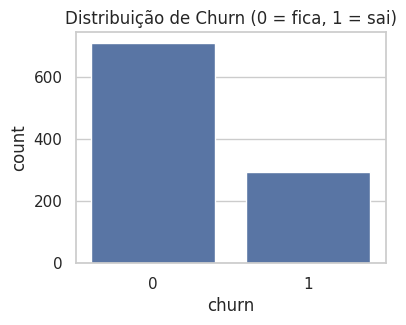

In [20]:
plt.figure(figsize=(4,3))
sns.countplot(x="churn", data=df)
plt.title("Distribuição de Churn (0 = fica, 1 = sai)")
plt.show()

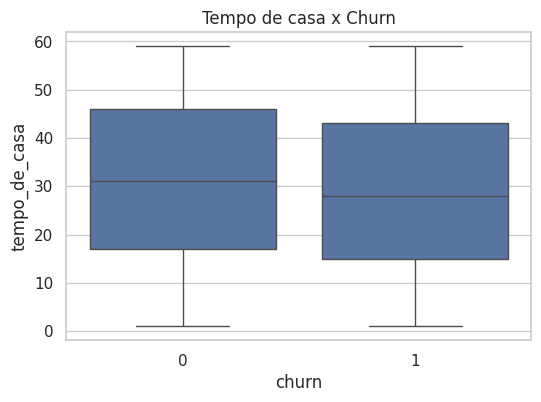

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x="churn", y="tempo_de_casa", data=df)
plt.title("Tempo de casa x Churn")
plt.show()

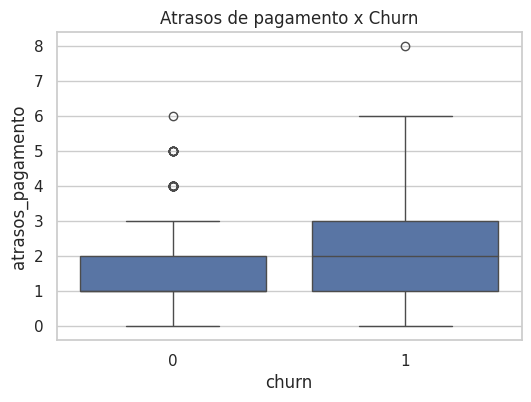

In [21]:
plt.figure(figsize=(6,4))
sns.boxplot(x="churn", y="atrasos_pagamento", data=df)
plt.title("Atrasos de pagamento x Churn")
plt.show()

Seção 3 – Pré-processamento

- Categóricas → dummies
- Split treino/teste
- Sem normalização (atenção para esse ponto!)

In [22]:
# Cópia para modelagem
df_model = df.copy()

# One-hot encoding para variáveis categóricas
df_model = pd.get_dummies(df_model, columns=["tipo_plano"], drop_first=True)

df_model.head()

,idade,tempo_de_casa,valor_mensal,atrasos_pagamento,usa_app,atendimentos_suporte,churn,tipo_plano_Intermediario,tipo_plano_Premium
0,56,11,99.9,2,1,0,0,True,False
1,69,21,159.9,1,1,1,1,False,False
2,46,26,79.9,3,1,0,1,False,True
3,32,25,99.9,0,0,1,0,True,False
4,60,22,79.9,2,1,1,0,True,False


IMPORTANTE:
- Diferente do KNN, aqui NÃO estamos normalizando os dados.
- Árvores de decisão não dependem da escala das variáveis.
- Elas só "perguntam" se uma feature é menor/maior que um certo valor (cortes).

In [23]:
# Separando features (X) e alvo (y)
X = df_model.drop("churn", axis=1)
y = df_model["churn"]

# Treino / teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((800, 8), (200, 8))

Seção 4 – Treinando a Decision Tree (modelo base)

In [25]:
# Criando e treinando a árvore de decisão (modelo base)
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predição no conjunto de teste
y_pred = clf.predict(X_test)

# Avaliação
acc = accuracy_score(y_test, y_pred)
print(f"Acurácia (teste) - Árvore sem restrições: {acc:.3f}")

Acurácia (teste) - Árvore sem restrições: 0.555


Matriz de confusão:

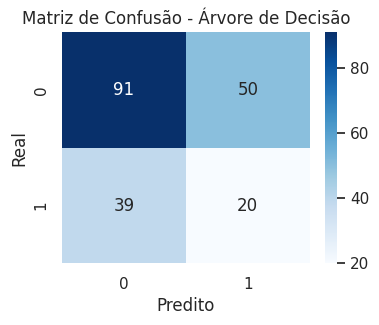

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Árvore de Decisão")
plt.show()

Opcional:

In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.65      0.67       141
           1       0.29      0.34      0.31        59

    accuracy                           0.56       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.58      0.56      0.56       200



Seção 5 – Interpretando a árvore (visualização simples)

Para não ficar gigante, limitar profundidade na visualização:

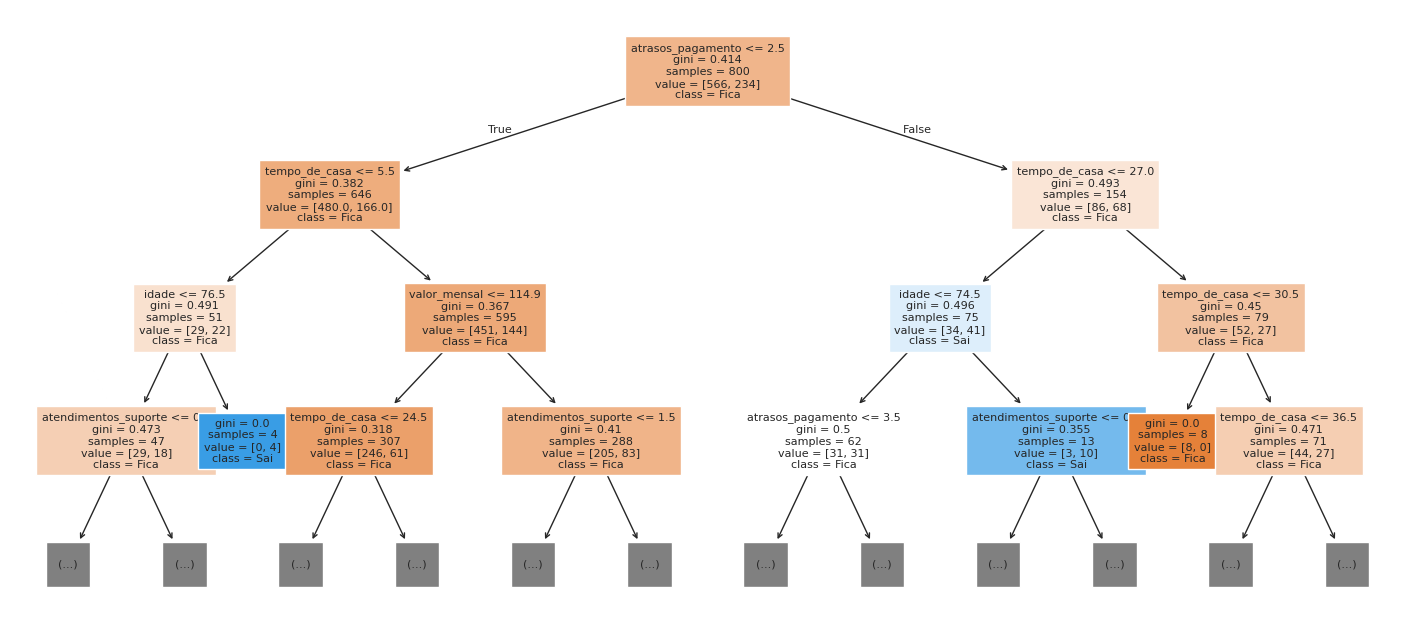

In [26]:
plt.figure(figsize=(18, 8))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["Fica", "Sai"],
    filled=True,
    max_depth=3,       # limitar profundidade apenas para visualização
    fontsize=8
)
plt.show()

### Perguntas para ler a árvore

- ### Leitura da árvore

- Qual é a **primeira pergunta** (raiz) que a árvore faz?  
- Faz sentido essa variável ser a primeira dividindo os clientes?
- Escolha um caminho da raiz até uma folha e traduza para linguagem de negócio.
  - Exemplo: "Clientes com **pouco tempo de casa** e **muitos atrasos de pagamento** têm alta chance de churn."

Seção 6 – Overfitting x Underfitting (max_depth)

Mostrar acurácia em treino x teste:

In [27]:
 # Acurácia no treino
y_train_pred = clf.predict(X_train)
acc_train = accuracy_score(y_train, y_train_pred)

print(f"Acurácia treino (árvore sem restrições): {acc_train:.3f}")
print(f"Acurácia teste  (árvore sem restrições): {acc:.3f}")

Acurácia treino (árvore sem restrições): 1.000
Acurácia teste  (árvore sem restrições): 0.555


Se a acurácia de treino for muito maior do que a de teste,
temos um forte sinal de **overfitting** (árvore "decorou" o conjunto de treino).

Depois, comparar com árvore “podada”:


LIMITANDO A PROFUNDIDADE

In [28]:
# Criando uma árvore com profundidade máxima = 4
clf2 = DecisionTreeClassifier(max_depth=4, random_state=42)
clf2.fit(X_train, y_train)

y_train_pred2 = clf2.predict(X_train)
y_test_pred2 = clf2.predict(X_test)

acc_train2 = accuracy_score(y_train, y_train_pred2)
acc_test2 = accuracy_score(y_test, y_test_pred2)

print("Árvore com max_depth = 4")
print(f"Acurácia treino: {acc_train2:.3f}")
print(f"Acurácia teste:  {acc_test2:.3f}")

Árvore com max_depth = 4
Acurácia treino: 0.735
Acurácia teste:  0.710


REFLEXÃO

- O que aconteceu com a acurácia de treino quando limitamos a profundidade?
- E com a acurácia de teste?
- Isso é um exemplo de **overfitting** ou **underfitting**?


Compare:

- Acurácia de treino (sem limite de profundidade) vs (max_depth=4)
- Acurácia de teste (sem limite de profundidade) vs (max_depth=4)

Discuta com o professor:
- Houve redução de overfitting?
- Algum dos modelos parece mais equilibrado entre treino e teste?

Se quiser, pode ainda visualizar essa árvore mais rasa:

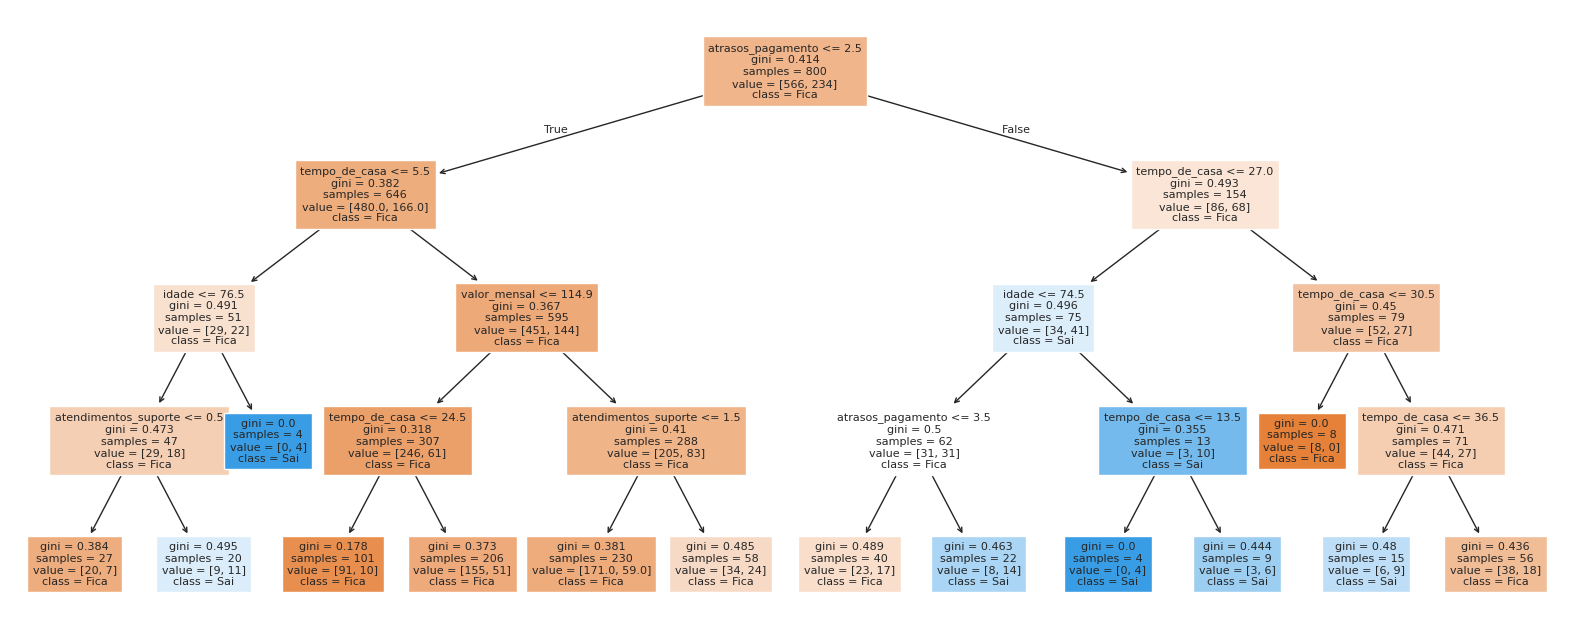

In [29]:
plt.figure(figsize=(20, 8))
plot_tree(
    clf2,
    feature_names=X.columns,
    class_names=["Fica", "Sai"],
    filled=True,
    max_depth=4,
    fontsize=8
)
plt.show()

Seção 7 – Importância das variáveis

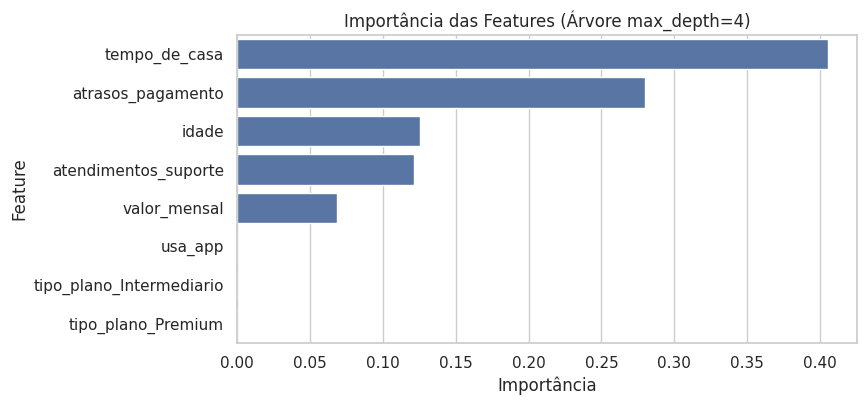

,0
tempo_de_casa,0.405288
atrasos_pagamento,0.279617
idade,0.125268
atendimentos_suporte,0.121508
valor_mensal,0.068319
usa_app,0.000000
tipo_plano_Intermediario,0.000000
tipo_plano_Premium,0.000000


In [30]:
importances = pd.Series(clf2.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Importância das Features (Árvore max_depth=4)")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.show()

importances

### Perguntas

- As variáveis mais importantes fazem sentido para explicar "churn" na vida real?
- As variáveis mais importantes fazem sentido para explicar churn?
- Se você fosse o gestor de marketing, quais ações tomaria olhando essas features?

Seção 8 – (Opcional) Random Forest Teaser

Se der tempo, QUE TAL um “sneak peek” de ensemble?

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Acurácia Random Forest:", accuracy_score(y_test, y_pred_rf))

Acurácia Random Forest: 0.685


EXPLICAÇÃO RÁPIDA

### O que é uma Random Forest?

- É um **conjunto de árvores de decisão**, cada uma treinada com:
  - uma amostra aleatória dos dados,
  - e uma amostra aleatória das variáveis.
- A predição final é o **voto da maioria** das árvores.
- Em geral, é **mais robusta** e generaliza melhor do que uma única árvore.

Seção 9 – Conclusão

### Conclusões da Aula

- Árvores de decisão aprendem **regras de decisão** (if/else) a partir dos dados.
- São modelos **interpretáveis**, bons para explicar decisões ao time de negócio.
- Precisam de cuidado com **overfitting**:
  - Árvores muito profundas tendem a "decorar" os dados de treino.
  - Hiperparâmetros como `max_depth`, `min_samples_leaf`, `min_samples_split` ajudam a controlar.
- Random Forest é um **ensemble** de árvores que tende a melhorar a performance e a robustez.

### Para pensar

1. Em quais problemas do seu trabalho ou da sua área um modelo interpretável é fundamental?
2. Que outras variáveis você sugeriria coletar para melhorar esse modelo de churn?
3. Se o modelo errar um churn (falso negativo ou falso positivo), qual é o impacto no negócio?